In [1]:
import polars as pl
import numpy as np
import seaborn as sns
import pandas as pd

In [2]:
# 1. Quando eu leio uma coluna de String é mais custoso que
# coluna numérica
# 2. Quando são diferentes não há o que fazer
# 3. Mas quando são repetitivas, posso otimizar usando:
# 3.1. No Polars: .cast(pl.Categorical)
# 3.2. No Pandas: .astype('category')
# a linha abaixo faz com o que o dicionario que mapeia
# um numero em relação a categoria seja global, ou seja,
# vai ser utilizado por qualquer outra tabela que seja lida
# no arquivo
pl.enable_string_cache()

In [3]:
df = pl.read_csv('03.BaseDPEvolucaoMensalCisp.csv',
                 separator=';', encoding='iso-8859-1')
df_dp = pl.read_csv('08.DP.csv', separator=',')

df = df.join(
    df_dp,
    left_on='cisp',
    right_on='codDP',
    how='left'
)

df.glimpse()

Rows: 34848
Columns: 65
$ cisp                       <i64> 1, 4, 5, 6, 7, 9, 10, 12, 13, 14
$ mes                        <i64> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1
$ ano                        <i64> 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2003
$ mes_ano                    <str> '2003m01', '2003m01', '2003m01', '2003m01', '2003m01', '2003m01', '2003m01', '2003m01', '2003m01', '2003m01'
$ aisp                       <i64> 5, 5, 5, 1, 1, 2, 2, 19, 19, 23
$ risp                       <i64> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1
$ munic                      <str> 'Rio de Janeiro', 'Rio de Janeiro', 'Rio de Janeiro', 'Rio de Janeiro', 'Rio de Janeiro', 'Rio de Janeiro', 'Rio de Janeiro', 'Rio de Janeiro', 'Rio de Janeiro', 'Rio de Janeiro'
$ mcirc                      <i64> 3304557, 3304557, 3304557, 3304557, 3304557, 3304557, 3304557, 3304557, 3304557, 3304557
$ regiao                     <str> 'Capital', 'Capital', 'Capital', 'Capital', 'Capital', 'Capital', 'Capital', 'Capital', 'Capital', 'Ca

In [4]:
df = df.with_columns(
    pl.col('munic').cast(pl.Categorical),
    pl.col('regiao').cast(pl.Categorical),
    pl.col('nome').cast(pl.Categorical)
)

In [5]:
# Correlação entre coluna 1 e coluna 2
coluna1 = 'roubo_veiculo'
coluna2 = 'recuperacao_veiculos'

In [29]:
# corr
corr = df.select(
    pl.corr(coluna1, coluna2)
).item()


In [11]:
# Por Municipio
df_municipio_agg = (
    df.group_by('regiao')
    .agg([
        pl.mean(coluna1).alias(f'media_{coluna1}'),
        pl.mean(coluna2).alias(f'media_{coluna2}')
    ])
)
df_municipio_agg.select(
    pl.corr(f'media_{coluna1}', f'media_{coluna2}')
)

media_roubo_veiculo
f64
0.984596


In [19]:
# Por Municipio + Ano
df_municipio_ano_agg = (
    df.group_by(['munic', 'ano'])
    .agg([
        pl.sum(coluna1).alias(f'total_{coluna1}'),
        pl.sum(coluna2).alias(f'total_{coluna2}')
    ])
)
print(df_municipio_ano_agg.filter(
    pl.col('munic') == 'Sumidouro'))

shape: (22, 4)
┌───────────┬──────┬─────────────────────┬────────────────────────────┐
│ munic     ┆ ano  ┆ total_roubo_veiculo ┆ total_recuperacao_veiculos │
│ ---       ┆ ---  ┆ ---                 ┆ ---                        │
│ cat       ┆ i64  ┆ i64                 ┆ i64                        │
╞═══════════╪══════╪═════════════════════╪════════════════════════════╡
│ Sumidouro ┆ 2024 ┆ 0                   ┆ 7                          │
│ Sumidouro ┆ 2021 ┆ 0                   ┆ 2                          │
│ Sumidouro ┆ 2003 ┆ 3                   ┆ 10                         │
│ Sumidouro ┆ 2017 ┆ 0                   ┆ 5                          │
│ Sumidouro ┆ 2004 ┆ 1                   ┆ 2                          │
│ …         ┆ …    ┆ …                   ┆ …                          │
│ Sumidouro ┆ 2016 ┆ 1                   ┆ 2                          │
│ Sumidouro ┆ 2012 ┆ 0                   ┆ 2                          │
│ Sumidouro ┆ 2008 ┆ 4                   ┆ 5     

In [20]:
# Por Municipio + Ano
df_municipio_ano_agg = (
    df.group_by(['munic', 'ano'])
    .agg([
        pl.corr(coluna1, coluna2)
        .alias(f'correlacao_{coluna1}_{coluna2}')
    ]).sort('ano')
)
df_municipio_ano_agg.filter(
    pl.col('munic') == 'Rio de Janeiro')

munic,ano,correlacao_roubo_veiculo_recuperacao_veiculos
cat,i64,f64
"""Rio de Janeiro""",2003,0.86475
"""Rio de Janeiro""",2004,0.850561
"""Rio de Janeiro""",2005,0.858212
"""Rio de Janeiro""",2006,0.751238
"""Rio de Janeiro""",2007,0.729301
…,…,…
"""Rio de Janeiro""",2020,0.704021
"""Rio de Janeiro""",2021,0.715899
"""Rio de Janeiro""",2022,0.689926


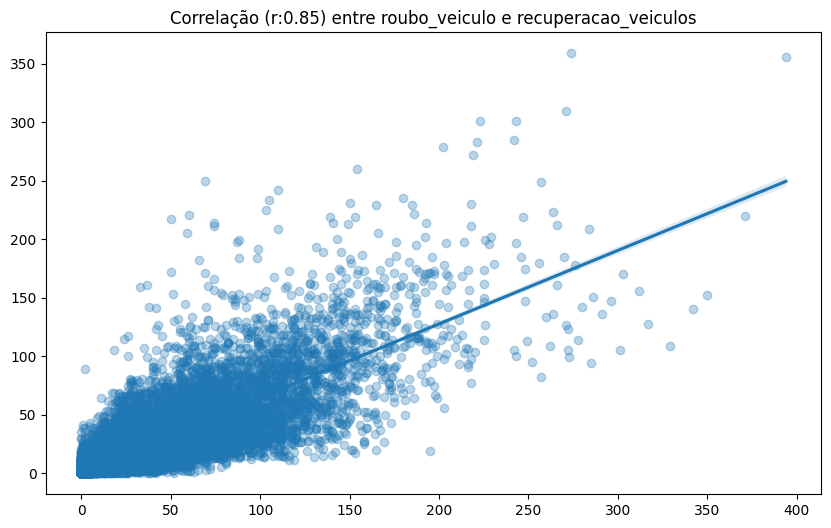

In [31]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df,
    x=coluna1,
    y = coluna2,
    scatter_kws={'alpha':0.3}
)
plt.title(f'Correlação (r:{corr:.2f}) entre {coluna1} e {coluna2}')
plt.show()